# Week 2 · Role B — Embed val images, mean-center, reduce dimensionality, cluster errors, build review grids

**Original plan:** embed all val images, mean-center, cluster the errors with
k-means (sweep k = 5/10/20), generate image grids per cluster.
**Ends with:** `clusters.csv` + grids for review.

**Pipeline in this version:** load Waterbirds from Hugging Face (§2) -> embed
by `image_id` (§9) -> mean-center, no renorm (§6) -> UMAP dimensionality
reduction (§11) -> HDBSCAN with a `min_cluster_size` sweep (§12-13) ->
`clusters.csv` + grids (§13-14).

**Data source changed to Hugging Face (`grodino/waterbirds`), replacing `wilds`.**
This is a bigger change than swapping one line: `wilds` downloads image files
to disk and gives you a folder path (`WATERBIRDS_IMAGE_ROOT`) that
`predictions.csv`'s `filepath` column joins onto; Hugging Face's `datasets`
library instead gives you an **in-memory table of decoded PIL images accessed
by row index**. There is no filesystem path at all in this version — every
cell that used to do `Image.open(full_path)` now does
`wilds_dataset[image_id]["image"]` instead. Concretely, this touched:

- **§2** — loads `grodino/waterbirds` via `datasets.load_dataset`, concatenates
  train/validation/test into one `wilds_dataset`, and assigns each row an
  `image_id` equal to its index (this must be the SAME indexing convention
  Role A used when generating `predictions.csv`'s `image_id` column, or the
  join will point at the wrong images — see the note in §8).
- **§8** — `predictions.csv` no longer needs (or uses) any `filepath` column;
  `image_id` is now the sole join key.
- **§9** — fetches PIL images by `wilds_dataset[image_id]["image"]` instead of
  opening a file path; caching now keys on `image_id` instead of `filepath`.
- **§13/§14** — `clusters.csv` now has `image_id` (not `image_name`, since no
  filename exists in this version) + `cluster` + `cluster_label`; grid
  thumbnails are labeled with `id=<image_id>` instead of a filename.

**Clustering method: HDBSCAN**, density-based, sweeping `min_cluster_size`
(unclustered points get `-1`/"noise" rather than being forced into a group).

**Why UMAP ahead of clustering:** raw CLIP embeddings (512-d for ViT-B/16)
suffer from the curse of dimensionality — pairwise distances concentrate in
high dimensions. UMAP preserves local neighborhood structure nonlinearly
before HDBSCAN's density estimates are computed.

**Fixes carried over from earlier debugging:**
1. Column names match your predictions.csv schema, configurable via `COLUMNS` (§7).
2. Embedding <-> image identity tracked explicitly via `image_id`, with an
   assertion on any cache load — never trust row position alone (§9).
3. Mean-centering does not renormalize to unit length afterward (§6).
4. HDBSCAN runs on a precomputed cosine distance matrix, not
   `metric="euclidean"`, since UMAP output isn't guaranteed unit-norm (§12).

**Note:** your file has no `place` column, so the Waterbirds-specific
known-group cross-check in §13 will simply report that it's skipping.

**Note on splits:** this notebook clusters the **val** split's errors — test
stays untouched for a later held-out transfer-proof stage. Change
`target_split="val"` to `"test"` in §8's call if you want to cluster test instead.

**CLIP model:** `ViT-B-16` / `laion2b_s34b_b88k` — same checkpoint as Week 1.

**Runtime:** GPU — `Runtime > Change runtime type > T4 GPU`.

## 1. Install dependencies

In [ ]:
!pip install -q open_clip_torch datasets hdbscan umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 1.5/1.5 MB 133.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/44.8 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


## 2. Load Waterbirds from Hugging Face (`grodino/waterbirds`)

Unlike the `wilds` package (which downloads image *files* to disk and gives you
a folder path), Hugging Face's `datasets` library gives you an in-memory
table where each row's image is a decoded PIL image accessed **by row index**,
not by filesystem path. This changes how images get fetched downstream: §9 and
§14 now pull `wilds_dataset[i]["image"]` directly instead of opening a file
path — there is no `WATERBIRDS_IMAGE_ROOT` in this version.

We inspect the actual column names at load time (printed below) rather than
assuming — Hugging Face dataset schemas vary by uploader, and guessing here is
exactly what caused the `NameError`/schema mismatches earlier.

In [ ]:
from datasets import load_dataset, concatenate_datasets
hf_dataset = load_dataset("grodino/waterbirds")
print("Available splits:", list(hf_dataset.keys()))
def add_id(example, idx):
    example["image_id"] = idx
    return example
wilds_dataset = concatenate_datasets([
    hf_dataset["train"],
    hf_dataset["validation"],
    hf_dataset["test"],])
wilds_dataset = wilds_dataset.map(add_id, with_indices=True)
print(f"Successfully loaded Hugging Face dataset! Total images: {len(wilds_dataset)}")
print("Columns:", wilds_dataset.column_names)
print("First row (image omitted):",
      {k: v for k, v in wilds_dataset[0].items() if k != "image"})

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  212MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 48.1MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating validation split:   0%|          | 0/1199 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5794 [00:00<?, ? examples/s]

Available splits: ['train', 'validation', 'test']


Map:   0%|          | 0/11788 [00:00<?, ? examples/s]

Successfully loaded Hugging Face dataset! Total images: 11788
Columns: ['image', 'label', 'place', 'bird', 'image_id']
First row (image omitted): {'label': 1, 'place': 1, 'bird': 0, 'image_id': 0}


## 3. Upload predictions.csv (Role A's handoff)
Run this cell, then use the file picker to select `predictions.csv`.

In [ ]:
from google.colab import files

uploaded = files.upload()
predictions_filename = next(iter(uploaded))
print(f"Uploaded: {predictions_filename}")


Saving predictions (3).csv to predictions (3).csv
Uploaded: predictions (3).csv


In [ ]:
from google.colab import files
uploaded = files.upload()
pf = next(iter(uploaded))

Saving slice_membership5.csv to slice_membership5.csv


In [ ]:
from google.colab import files
uploaded = files.upload()
pre = next(iter(uploaded))
print(f"Uploaded: {pre}")


Saving slice_names5.csv to slice_names5.csv
Uploaded: slice_names5.csv


## 4. Imports + device check

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import umap
import hdbscan

import open_clip

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected — go to Runtime > Change runtime type > GPU.")

CLIP_MODEL_NAME = "ViT-L-14"
CLIP_PRETRAINED = "laion2b_s32b_b82k"


Using device: cuda


## 5. CLIP setup + embedding function (identical to Week 1 — do not let these drift apart)

In [ ]:
def load_clip():
    model, _, preprocess = open_clip.create_model_and_transforms(
        CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED
    )
    model = model.to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, preprocess

model, preprocess = load_clip()
print(f"Loaded {CLIP_MODEL_NAME} ({CLIP_PRETRAINED}) on {DEVICE}")
@torch.no_grad()
def embed_images(model, preprocess, pil_images, batch_size=256):
    embeddings = []
    for i in range(0, len(pil_images), batch_size):
        batch = torch.stack(
            [preprocess(im) for im in pil_images[i : i + batch_size]]
        ).to(DEVICE)
        feats = model.encode_image(batch)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        embeddings.append(feats.cpu())
    return torch.cat(embeddings)


open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.71GB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

Loaded ViT-L-14 (laion2b_s32b_b82k) on cuda


## 6. Mean-centering — corrected (no renormalization)

Center only. Do not renormalize back to unit length afterward — subtracting
the mean gives an exact zero-mean set, but dividing each result back to unit
length is nonlinear: it silently undoes that zero-mean property and
disproportionately amplifies noise for images that were close to the mean
direction to begin with. UMAP's cosine metric (§11) still works correctly on
these non-unit-norm vectors, since cosine distance normalizes internally.

In [ ]:
def compute_mean_embedding(embeddings: torch.Tensor) -> torch.Tensor:
    return embeddings.mean(dim=0)
def mean_center(embeddings: torch.Tensor, mean_vec: torch.Tensor) -> torch.Tensor:
    """Center only — no renormalization."""
    return embeddings - mean_vec.unsqueeze(0)

## 7. Configuration

`COLUMNS` maps this notebook's internal names to whatever your actual
predictions.csv calls them. **Your file uses:**
`image_id, filepath, true_label, pred_label, is_error, split` — already set
below. If Role A's schema changes again later, this is the only place to edit.

In [ ]:
OUTPUT_DIR = "/content/week2_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_CLUSTER_SIZES = [8]     
CHOSEN_MIN_CLUSTER_SIZE = None      

UMAP_N_COMPONENTS = 40   
UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.0        
WILDS_SPLIT_CODE = {"train": 0, "val": 1, "test": 2}   

COLUMNS = {
    "image_id": "image_id",        
    "true_label": "true_label",
    "pred_label": "pred_label",
    "is_error": "is_error",        
    "split": "split",
    "place": "place",              
}


## 8. Load predictions.csv and isolate the VAL split only

**No `filepath`/`full_path` in this version.** Since images now come from the
in-memory `wilds_dataset` (Hugging Face), the only thing predictions.csv needs
to provide is `image_id` — the row index into `wilds_dataset` — everything
else (fetching the actual image, its true label, etc.) is looked up from
`wilds_dataset` directly at embedding/plotting time.

Fails loudly with the actual column list if any expected column is missing.

In [ ]:
def load_predictions(predictions_csv_path, columns, target_split="val"):
    df = pd.read_csv(predictions_csv_path)

    required = [columns["image_id"], columns["true_label"], columns["pred_label"], columns["split"]]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"predictions.csv is missing expected column(s) {missing}. "
            f"Actual columns found: {df.columns.tolist()}. "
            f"Fix the COLUMNS dict in the config cell above to match."
        )

    split_col = columns["split"]
    if df[split_col].dtype == object or pd.api.types.is_string_dtype(df[split_col]):
        split_mask = df[split_col].astype(str).str.lower() == target_split
    else:
        split_mask = df[split_col] == WILDS_SPLIT_CODE[target_split]

    df = df[split_mask].reset_index(drop=True)
    return df

df = load_predictions(predictions_filename, COLUMNS, target_split="val")
print(f"{len(df)} VAL images isolated out of the full predictions.csv")
df.head()


4715 VAL images isolated out of the full predictions.csv


,image_id,true_label,pred_label,is_error,split
0,1,1,1,0,val
1,2,1,1,0,val
2,3,1,0,1,val
3,12,1,1,0,val
4,13,1,1,0,val


## 9. Embed + mean-center the FULL val set — fetching images by `image_id`

Images are pulled directly from `wilds_dataset[image_id]["image"]` (already a
decoded PIL image, no disk path involved). The mean vector is computed over
the **entire val split**, not just the error subset.

Embeddings are cached alongside `image_id` (not just as a bare array), and any
cache hit is checked against the *current* dataframe before being trusted —
array position is a convenience, `image_id` is the real key, always.

In [ ]:
def fetch_pil_images_by_id(wilds_dataset, image_ids):
    """Looks up decoded PIL images from the in-memory HF dataset by row index.
    Adjust the key below ("image") if your dataset's image column is named
    differently -- check the printed column list from §2 if this KeyErrors."""
    return [wilds_dataset[int(i)]["image"].convert("RGB") for i in image_ids]
def embed_and_center_val_set(df, wilds_dataset, model, preprocess, id_col, cache_path=None):
    image_ids = df[id_col].tolist()
    if cache_path and os.path.exists(cache_path):
        cached = np.load(cache_path, allow_pickle=True)
        cached_ids = cached["image_ids"].tolist()
        assert cached_ids == image_ids, (
            "Cached embeddings don't match the current dataframe's row order/content — "
            "delete the cache file and re-embed. Never trust array position alone."
        )
        raw = torch.from_numpy(cached["embeddings"])
        print(f"[embed] loaded {len(image_ids)} cached embeddings, image_ids verified to match df")
    else:
        pil_images = fetch_pil_images_by_id(wilds_dataset, image_ids)
        raw = embed_images(model, preprocess, pil_images)
        if cache_path:
            np.savez(cache_path, embeddings=raw.numpy(), image_ids=np.array(image_ids, dtype=object))
    mean_vec = compute_mean_embedding(raw)
    centered = mean_center(raw, mean_vec)
    return raw, centered, mean_vec
_, centered_all, mean_vec = embed_and_center_val_set(
    df, wilds_dataset, model, preprocess, COLUMNS["image_id"],
    cache_path=os.path.join(OUTPUT_DIR, "val_embeddings.npz")
)
np.save(os.path.join(OUTPUT_DIR, "val_mean_vector.npy"), mean_vec.numpy())
print("Embedded + centered:", centered_all.shape)
print("max|mean(centered)| =", centered_all.mean(dim=0).abs().max().item(), "(should be ~0)")


Embedded + centered: torch.Size([4715, 768])
max|mean(centered)| = 2.588977920936486e-08 (should be ~0)


## 10. Isolate the error subset

Uses `is_error` directly if present (Role A already computed it); falls back
to `pred_label != true_label` otherwise.

In [ ]:
if COLUMNS["is_error"] in df.columns:
    error_mask = df[COLUMNS["is_error"]].astype(bool).values
else:
    error_mask = (df[COLUMNS["pred_label"]] != df[COLUMNS["true_label"]]).values
error_df = df[error_mask].reset_index(drop=True)
error_embeddings = centered_all[error_mask].numpy()   
print(f"{len(error_df)} / {len(df)} val images misclassified ({error_mask.mean():.1%})")
assert list(error_df[COLUMNS["image_id"]]) == list(df.loc[error_mask, COLUMNS["image_id"]])


348 / 4715 val images misclassified (7.4%)


**VALIDATION**

In [ ]:
import numpy as np
import pandas as pd
import umap
import hdbscan
from sklearn.metrics.pairwise import cosine_distances


N_COMPONENTS_GRID = [15, 30, 50]
N_NEIGHBORS_GRID = [8, 10, 15]
MIN_CLUSTER_SIZE_GRID = [5, 8, 12,16]
SELECTION_METHOD_GRID = ["eom", "leaf"]


def run_sweep(error_embeddings, umap_min_dist=0.0, random_state=0):
    results = []
    
    
    umap_cache = {}

    for n_components in N_COMPONENTS_GRID:
        for n_neighbors in N_NEIGHBORS_GRID:
            key = (n_components, n_neighbors)
            if key not in umap_cache:
                reducer = umap.UMAP(
                    n_components=n_components,
                    n_neighbors=n_neighbors,
                    min_dist=umap_min_dist,
                    metric="cosine",
                    random_state=random_state,
                )
                umap_cache[key] = reducer.fit_transform(error_embeddings)
            reduced = umap_cache[key]
            dist_matrix = cosine_distances(reduced).astype(np.float64)

            for min_cluster_size in MIN_CLUSTER_SIZE_GRID:
                for method in SELECTION_METHOD_GRID:
                    clusterer = hdbscan.HDBSCAN(
                        min_cluster_size=min_cluster_size,
                        min_samples=max(3, min_cluster_size // 2),
                        metric="precomputed",
                        cluster_selection_method=method,
                        gen_min_span_tree=True,   
                    )
                    labels = clusterer.fit_predict(dist_matrix)
                    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                    noise_frac = (labels == -1).mean()

                    
                    
                    try:
                        validity = clusterer.relative_validity_ if n_clusters >= 2 else float("nan")
                    except AttributeError:
                        validity = float("nan")

                    results.append({
                        "n_components": n_components,
                        "n_neighbors": n_neighbors,
                        "min_cluster_size": min_cluster_size,
                        "selection_method": method,
                        "n_clusters": n_clusters,
                        "noise_fraction": round(noise_frac, 3),
                        "validity_score": round(validity, 4) if validity == validity else None,  
                    })

    return pd.DataFrame(results)


sweep_results_df = run_sweep(error_embeddings)



sweep_results_df = sweep_results_df.sort_values(
    ["validity_score", "n_clusters"], ascending=[False, False]
).reset_index(drop=True)

print("Top 10 settings by validity score (higher = more genuinely distinct density-based clusters):")
print(sweep_results_df.head(10).to_string(index=False))

sweep_results_df.to_csv("hyperparameter_sweep_results.csv", index=False)
print(f"\nFull sweep ({len(sweep_results_df)} combinations) saved to hyperparameter_sweep_results.csv")
print("\nPick the top-validity row that ALSO has a noise_fraction and n_clusters you're comfortable with —")
print("validity score should narrow your choices, but still confirm with cluster grids before finalizing.")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

Top 10 settings by validity score (higher = more genuinely distinct density-based clusters):
 n_components  n_neighbors  min_cluster_size selection_method  n_clusters  noise_fraction  validity_score
           50           10                 8              eom          18           0.132          0.3953
           50           10                 8             leaf          19           0.141          0.3746
           15            8                 8              eom          18           0.109          0.3533
           15            8                 8             leaf          18           0.109          0.3533
           15            8                 5              eom          22           0.109          0.3331
           50            8                 5              eom          24           0.089          0.3206
           30            8                 5              eom          22           0.118          0.3202
           30            8                 8             le

## 11. Dimensionality reduction with UMAP (new)

We reduce `error_embeddings` from its native CLIP dimensionality (512-d for
ViT-B/16) down to `UMAP_N_COMPONENTS` before clustering, rather than clustering
directly in the raw embedding space.

**Why this captures more of the meaningful structure, not less:** UMAP builds
a fuzzy k-nearest-neighbor graph in the original high-dimensional space (using
`n_neighbors` to define "local"), then optimizes low-dimensional coordinates so
that a matching neighborhood graph in the reduced space has minimal
cross-entropy against the original. This preserves *local* neighborhood
relationships nonlinearly — two images that are genuinely similar in a curved
region of the embedding manifold stay close together in the reduced space,
even if a linear method like PCA (which only preserves directions of highest
*global* variance) would have pulled them apart. Combined with the
curse-of-dimensionality argument in the notebook intro, this gives K-means a
space where Euclidean distance is a much more meaningful notion of
"similar failure" than it is in the raw 512-d space.

We use `metric="cosine"` for the UMAP fit itself (appropriate for CLIP-derived
embeddings regardless of their current norm, since cosine distance normalizes
internally), then hand K-means the resulting Euclidean coordinates directly.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced 768-d embeddings -> 40-d


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


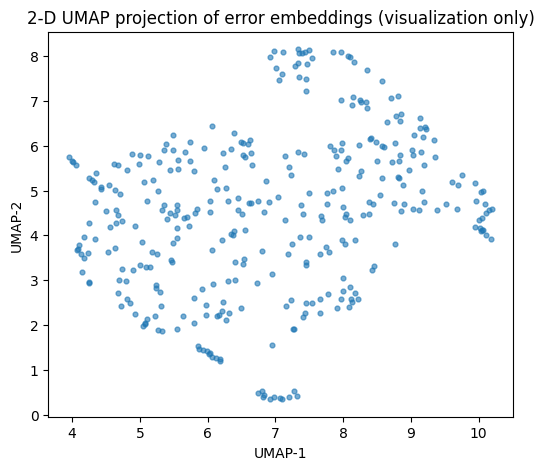

In [ ]:
reducer = umap.UMAP(
    n_components=UMAP_N_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=0,
)
reduced_embeddings = reducer.fit_transform(error_embeddings)   
print(f"UMAP reduced {error_embeddings.shape[1]}-d embeddings -> {reduced_embeddings.shape[1]}-d")

np.save(os.path.join(OUTPUT_DIR, "error_embeddings_umap.npy"), reduced_embeddings)




reducer_2d = umap.UMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS, min_dist=0.1, metric="cosine", random_state=0)
viz_2d = reducer_2d.fit_transform(error_embeddings)
plt.figure(figsize=(6, 5))
plt.scatter(viz_2d[:, 0], viz_2d[:, 1], s=12, alpha=0.6)
plt.title("2-D UMAP projection of error embeddings (visualization only)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()


## 12. Sweep HDBSCAN over `min_cluster_size` on the UMAP-reduced embeddings

For each candidate `min_cluster_size`, fit HDBSCAN on `reduced_embeddings` (not
the raw 512-d embeddings) and record the resulting cluster count + noise
fraction. Unlike K-means, HDBSCAN does not force every point into a cluster —
points that aren't part of any sufficiently dense region get labeled `-1`
("noise"), which matters here because some validation errors are genuine
one-off mistakes with no shared cause; forcing them into the nearest cluster
would corrupt that cluster's name later (Role C).

We compute a precomputed cosine **distance** matrix rather than relying on
`metric="euclidean"`, since the UMAP-reduced coordinates are not guaranteed to
be unit-norm (UMAP was fit with `metric="cosine"` internally, but its output
coordinates are just Euclidean coordinates in the reduced space — using an
explicit cosine-distance matrix keeps the clustering step consistent with the
same cosine geometry CLIP's embeddings were originally organized under).

In [ ]:
def sweep_hdbscan_cosine(reduced_embeddings, min_cluster_sizes=(20)):
    dist_matrix = cosine_distances(reduced_embeddings).astype(np.float64)
    rows, fitted = [], {}
    for mcs in min_cluster_sizes:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=max(3, mcs // 2),
            metric="precomputed",
        )
        labels = clusterer.fit_predict(dist_matrix)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = (labels == -1).mean()
        rows.append({"min_cluster_size": mcs, "n_clusters": n_clusters, "noise_fraction": round(noise_frac, 3)})
        fitted[mcs] = labels
        print(f"  min_cluster_size={mcs:>3}  ->  {n_clusters} clusters, {noise_frac:.1%} noise")
    return pd.DataFrame(rows), fitted

sweep_table, fitted_by_mcs = sweep_hdbscan_cosine(reduced_embeddings, min_cluster_sizes=MIN_CLUSTER_SIZES)
sweep_table.to_csv(os.path.join(OUTPUT_DIR, "hdbscan_sweep_summary.csv"), index=False)
sweep_table


  min_cluster_size=  8  ->  14 clusters, 14.7% noise


,min_cluster_size,n_clusters,noise_fraction
0,8,14,0.147


## 13. Pick a setting from the sweep table, write clusters.csv, and (debug-only) cross-check against the known `place` group

`clusters.csv` explicitly includes `image_id`, `filepath` (the image name/path),
and the cluster assignment in both integer (`cluster`) and labeled string form
(`cluster_label`, e.g. `"cluster 0"` or `"cluster -1"` for noise).

In [ ]:
chosen_mcs = CHOSEN_MIN_CLUSTER_SIZE or MIN_CLUSTER_SIZES[len(MIN_CLUSTER_SIZES) // 2]
labels = fitted_by_mcs[chosen_mcs]
print(f"Using min_cluster_size={chosen_mcs} for clusters.csv + grids "
      f"(re-run this cell with CHOSEN_MIN_CLUSTER_SIZE set once the team decides from the sweep table)")


def debug_crosscheck_against_known_groups(error_df, labels, place_col):
    """Waterbirds is unusual in that we actually know the 'true' spurious
    factor (background place). If your predictions.csv doesn't carry it, this
    simply skips."""
    if place_col not in error_df.columns:
        print(f"[debug] '{place_col}' column not found in predictions.csv — skipping known-group cross-check.")
        return
    check_df = error_df.copy()
    check_df["cluster"] = labels
    crosstab = pd.crosstab(check_df["cluster"], check_df[place_col])
    print("\n[debug cross-check] cluster vs. known background group (place):")
    print(crosstab)

debug_crosscheck_against_known_groups(error_df, labels, COLUMNS["place"])



clusters_out = error_df[[COLUMNS["image_id"]]].copy()
clusters_out = clusters_out.rename(columns={COLUMNS["image_id"]: "image_id"})
clusters_out["cluster"] = labels
clusters_out["cluster_label"] = [("cluster noise" if c == -1 else f"cluster {c}") for c in labels]

clusters_out.to_csv(os.path.join(OUTPUT_DIR, "clusters.csv"), index=False)
print(f"\nclusters.csv written to '{OUTPUT_DIR}/' with columns: "
      f"{clusters_out.columns.tolist()}")
print(clusters_out.head())
print(f"\nnote: unlike K-means, HDBSCAN assigns -1 ('cluster noise') to points that "
      f"don't belong to any sufficiently dense cluster — these are NOT forced into a group.")


Using min_cluster_size=8 for clusters.csv + grids (re-run this cell with CHOSEN_MIN_CLUSTER_SIZE set once the team decides from the sweep table)
[debug] 'place' column not found in predictions.csv — skipping known-group cross-check.

clusters.csv written to '/content/week2_outputs/' with columns: ['image_id', 'cluster', 'cluster_label']
   image_id  cluster  cluster_label
0         3       10     cluster 10
1        25       10     cluster 10
2        50        4      cluster 4
3       106       -1  cluster noise
4       109       -1  cluster noise

note: unlike K-means, HDBSCAN assigns -1 ('cluster noise') to points that don't belong to any sufficiently dense cluster — these are NOT forced into a group.


## 14. Generate image grids per cluster (for the whole-team checkpoint review)

In [ ]:
def save_cluster_grids(error_df, wilds_dataset, labels, output_dir, id_col, images_per_cluster=9):
    os.makedirs(output_dir, exist_ok=True)
    df_ = error_df.copy()
    df_["cluster"] = labels

    for cluster_id in sorted(set(labels)):
        subset = df_[df_["cluster"] == cluster_id]
        sample = subset.sample(min(images_per_cluster, len(subset)), random_state=0)

        n = len(sample)
        cols = min(3, n)
        rows_ = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows_, cols, figsize=(3 * cols, 3 * rows_))
        axes = np.atleast_1d(axes).flatten()

        for ax, (_, row) in zip(axes, sample.iterrows()):
            img = wilds_dataset[int(row[id_col])]["image"].convert("RGB")
            ax.imshow(img)
            ax.set_title(f"id={row[id_col]}", fontsize=7)
            ax.axis("off")
        for ax in axes[n:]:
            ax.axis("off")

        fig.suptitle(f"cluster {cluster_id}  (n={len(subset)})")
        fig.tight_layout()
        fig.savefig(os.path.join(output_dir, f"cluster_{cluster_id}.png"), dpi=110)
        plt.show()
        plt.close(fig)
    print(f"[grids] saved {len(set(labels))} grid images to '{output_dir}/'")

save_cluster_grids(error_df, wilds_dataset, labels, os.path.join(OUTPUT_DIR, "grids"), COLUMNS["image_id"])


Output hidden; open in https://colab.research.google.com to view.

## 15. CHECKPOINT (whole team)

Look at the cluster grids together (each thumbnail is labeled with its
filename, and every image also appears in `clusters.csv` alongside its
`image_id` and `cluster_label`).

**Is at least one cluster visibly birds-on-mismatched-background?**

- **If yes:** proceed to Role C's naming step.
- **If no:** stop and debug (re-check mean-centering, try different
  `UMAP_N_COMPONENTS`/`n_neighbors`, or a different `k`) before spending a
  week naming clusters that aren't real. **Do not skip this.**

## Appendix — swapping the CLIP model

You can change `CLIP_MODEL_NAME` / `CLIP_PRETRAINED`, but two things to keep in mind:

1. **The pretrained tag must actually exist for that architecture.** Check with:
   ```python
   import open_clip
   for name, tag in open_clip.list_pretrained():
       if "ViT-L-14" in name:
           print(name, tag)
   ```
2. **Embedding dimension can change** (e.g. ViT-L/14 is 768-d vs. ViT-B/16's 512-d).
   Nothing here hardcodes a dimension, but embeddings from two different models
   are never comparable — if you switch models, delete the cached `.npz` files
   in both this notebook and Week 1's, and re-embed everything with the new
   model consistently. Week 1 and Week 2 must always use the identical
   `(CLIP_MODEL_NAME, CLIP_PRETRAINED)` pair, since Week 2's mean vector is
   specific to whichever model produced the embeddings it's centering.

In [ ]:
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)

=== Step 1: inspect the dendrogram, pick a threshold where there's a clear gap ===


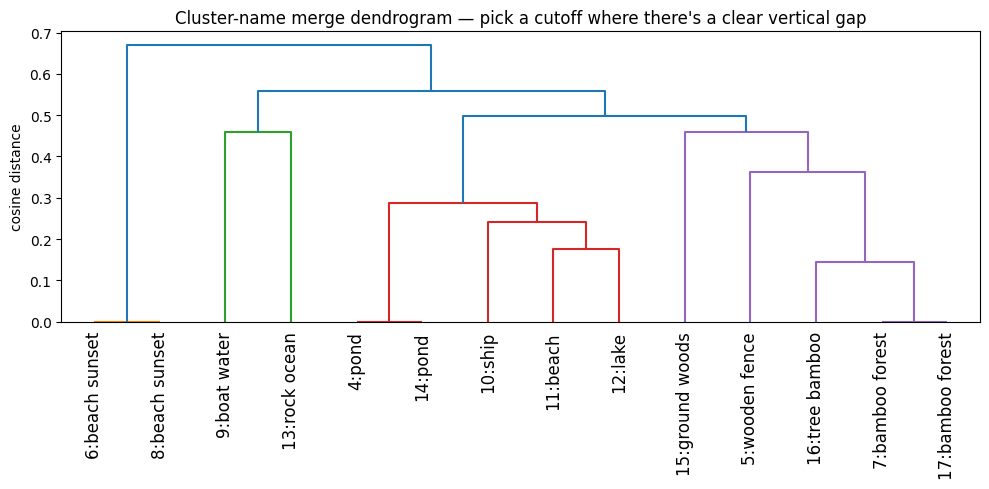


=== Step 2: merge result at threshold=0.25 ===
MERGED   merged_group= 1  canonical='beach sunset'  members=[(6, 'beach sunset'), (8, 'beach sunset')]
standalone merged_group= 2  canonical='boat water'  members=[(9, 'boat water')]
standalone merged_group= 3  canonical='rock ocean'  members=[(13, 'rock ocean')]
MERGED   merged_group= 4  canonical='pond'  members=[(4, 'pond'), (14, 'pond')]
MERGED   merged_group= 5  canonical='lake'  members=[(10, 'ship'), (11, 'beach'), (12, 'lake')]
MERGED   merged_group= 6  canonical='bamboo forest'  members=[(7, 'bamboo forest'), (16, 'tree bamboo'), (17, 'bamboo forest')]
standalone merged_group= 7  canonical='wooden fence'  members=[(5, 'wooden fence')]
standalone merged_group= 8  canonical='ground woods'  members=[(15, 'ground woods')]

Total merged groups: 8 (down from 14)

=== Step 3: flag weak/non-discriminative clusters for manual review ===
Clusters flagged for manual review (bottom 15% by contrastive score, score <= 0.0765):
 cluster_id   to

In [ ]:
import numpy as np
import pandas as pd
import torch
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt


@torch.no_grad()
def clip_embed_text(strings, clip_model, clip_tokenizer, device):
    tokens = clip_tokenizer(strings).to(device)
    feats = clip_model.encode_text(tokens)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()


def plot_dendrogram(embeddings, labels):
    from scipy.spatial.distance import pdist
    condensed_dist = pdist(embeddings, metric="cosine")
    Z = linkage(condensed_dist, method="average")

    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=labels, leaf_rotation=90)
    plt.ylabel("cosine distance")
    plt.title("Cluster-name merge dendrogram — pick a cutoff where there's a clear vertical gap")
    plt.tight_layout()
    plt.show()
    return Z


def merge_clusters(names_df, Z, distance_threshold):
    
    merged_labels = fcluster(Z, t=distance_threshold, criterion="distance")
    out = names_df.copy()
    out["merged_group"] = merged_labels

    canonical = (
        out.sort_values("score", ascending=False)
        .drop_duplicates("merged_group")
        .set_index("merged_group")["top_phrase"]
    )
    out["merged_name"] = out["merged_group"].map(canonical)
    return out


def flag_weak_clusters(names_df, score_percentile=15):
    threshold = np.percentile(names_df["score"], score_percentile)
    weak = names_df[names_df["score"] <= threshold]
    print(f"Clusters flagged for manual review (bottom {score_percentile}% by contrastive score, "
          f"score <= {threshold:.4f}):")
    print(weak[["cluster_id", "top_phrase", "score", "top_5_phrases"]].to_string(index=False))
    print("\nReview each one's top_5_phrases by eye -- drop only the ones that genuinely look like")
    print("noise/body-parts/generic-color words, not every low-score row automatically.")
    return weak

names_df = pd.read_csv("slice_names5.csv")

cluster_names = names_df["top_phrase"].tolist()
text_embs = clip_embed_text(cluster_names, model, clip_tokenizer, DEVICE)

print("=== Step 1: inspect the dendrogram, pick a threshold where there's a clear gap ===")
dendro_labels = [f"{cid}:{name}" for cid, name in
                 zip(names_df["cluster_id"], cluster_names)]
Z = plot_dendrogram(text_embs, labels=dendro_labels)


DISTANCE_THRESHOLD = 0.25   

merged_df = merge_clusters(names_df, Z, DISTANCE_THRESHOLD)
print(f"\n=== Step 2: merge result at threshold={DISTANCE_THRESHOLD} ===")
for group_id, group_df in merged_df.groupby("merged_group"):
    members = list(zip(group_df["cluster_id"], group_df["top_phrase"]))
    tag = "MERGED  " if len(members) > 1 else "standalone"
    canonical_name = group_df["merged_name"].iloc[0]
    print(f"{tag} merged_group={group_id:2d}  canonical='{canonical_name}'  members={members}")
print(f"\nTotal merged groups: {merged_df['merged_group'].nunique()} (down from {len(names_df)})")

print("\n=== Step 3: flag weak/non-discriminative clusters for manual review ===")
weak_clusters_df = flag_weak_clusters(merged_df.drop_duplicates("merged_group"))


GROUPS_TO_DROP = []  

pruned_names_df = (
    merged_df[~merged_df["merged_group"].isin(GROUPS_TO_DROP)]
    .drop_duplicates("merged_group")[["merged_group", "merged_name"]]
    .rename(columns={"merged_group": "cluster_id", "merged_name": "top_phrase"})
    .reset_index(drop=True)
)
pruned_names_df.to_csv("slice_names_pruned.csv", index=False)
print(f"\nWrote slice_names_pruned.csv: {len(pruned_names_df)} final clusters")


membership_df = pd.read_csv("slice_membership5.csv")
old_to_merged = merged_df.set_index("cluster_id")["merged_group"].to_dict()

remapped_df = membership_df.copy()
remapped_df["merged_slice_id"] = remapped_df["slice_id"].map(old_to_merged)

remapped_df = remapped_df[~remapped_df["merged_slice_id"].isin(GROUPS_TO_DROP)]
remapped_df = remapped_df.drop(columns=["slice_id"]).rename(columns={"merged_slice_id": "slice_id"})

remapped_df.to_csv("slice_membership_pruned.csv", index=False)
print(f"Wrote slice_membership_pruned.csv: {len(remapped_df)} rows "
      f"(was {len(membership_df)} before dropping/remapping)")

In [ ]:
import pandas as pd
import os
GROUP_ID = {
    (0, 0): 0,  
    (0, 1): 1,  
    (1, 0): 2,  
    (1, 1): 3,  
}
GROUP_NAME = {
    0: "landbird_on_land",
    1: "landbird_on_water",
    2: "waterbird_on_land",
    3: "waterbird_on_water",
}
def get_ground_truth_groups(val_image_ids, wilds_dataset=None, cached_csv_path="val_ground_truth_groups.csv",
                             label_col="label", place_col="place"):
    """
    Returns a DataFrame [image_id, slice_id, cluster_name] for the ground-truth
    Waterbirds group of every id in val_image_ids. Uses the cached CSV from
    the earlier script if present; otherwise computes it fresh from
    wilds_dataset (must be passed in if no cache exists).
    """
    if os.path.exists(cached_csv_path):
        cached = pd.read_csv(cached_csv_path)
        lookup = cached.set_index("image_id")[["group", "group_name"]]
        lookup = lookup.rename(columns={"group": "slice_id", "group_name": "cluster_name"})
        return lookup.loc[list(val_image_ids)].reset_index()

    if wilds_dataset is None:
        raise ValueError(
            f"No cache found at '{cached_csv_path}' and no wilds_dataset provided — "
            f"need one or the other to compute ground-truth groups."
        )

    rows = []
    for image_id in val_image_ids:
        example = wilds_dataset[int(image_id)]
        true_label = int(example[label_col])
        place = int(example[place_col])
        group = GROUP_ID[(true_label, place)]
        rows.append({"image_id": image_id, "slice_id": group, "cluster_name": GROUP_NAME[group]})
    return pd.DataFrame(rows)



pred_df = pd.read_csv("predictions (3).csv")
membership_df = pd.read_csv("slice_membership_pruned.csv")     
names_df = pd.read_csv("slice_names_pruned.csv")                

val_df = pred_df[pred_df["split"] == "val"].reset_index(drop=True)
val_image_ids = val_df["image_id"].tolist()
print(f"{len(val_df)} val images total, {len(membership_df)} already have a discovered slice_id")


named_membership = membership_df.merge(
    names_df[["cluster_id", "top_phrase"]],
    left_on="slice_id", right_on="cluster_id", how="left"
).rename(columns={"top_phrase": "cluster_name"})[["image_id", "slice_id", "cluster_name"]]
named_membership["source"] = "discovered"

print("\nSample of discovered (named) rows:")
print(named_membership.head())



fallback_list = [i for i in val_image_ids if i not in set(membership_df["image_id"])]
fallback_df = get_ground_truth_groups(
    fallback_list,
    wilds_dataset=wilds_dataset if "wilds_dataset" in dir() else None,
)
fallback_df["source"] = "ground_truth"

print(f"\n{len(fallback_list)} val images fall back to ground-truth group")
print(fallback_df.head())



result_df = pd.concat(
    [named_membership, fallback_df[["image_id", "slice_id", "cluster_name", "source"]]],
    ignore_index=True,
)
result_df = result_df.sort_values("image_id").reset_index(drop=True)

assert len(result_df) == len(val_df), "final row count must equal total val images"
assert result_df["image_id"].is_unique, "each val image should appear exactly once"
assert (result_df["source"] == "discovered").sum() == len(membership_df)

result_df.to_csv("final_cluster_assignment.csv", index=False)
print(f"\nWrote final_cluster_assignment.csv: {len(result_df)} rows "
      f"({(result_df['source']=='discovered').sum()} discovered + "
      f"{(result_df['source']=='ground_truth').sum()} ground-truth fallback)")
print("\nSource breakdown:")
print(result_df["source"].value_counts())
print("\ncluster_name breakdown:")
print(result_df["cluster_name"].value_counts())

4715 val images total, 297 already have a discovered slice_id

Sample of discovered (named) rows:
   image_id  slice_id  cluster_name      source
0         3         4          pond  discovered
1        25         4          pond  discovered
2        50         1  beach sunset  discovered
3       111         5          lake  discovered
4       113         8  ground woods  discovered

4418 val images fall back to ground-truth group
   image_id  slice_id        cluster_name        source
0         1         3  waterbird_on_water  ground_truth
1         2         3  waterbird_on_water  ground_truth
2        12         3  waterbird_on_water  ground_truth
3        13         2   waterbird_on_land  ground_truth
4        14         3  waterbird_on_water  ground_truth

Wrote final_cluster_assignment.csv: 4715 rows (297 discovered + 4418 ground-truth fallback)

Source breakdown:
source
ground_truth    4418
discovered       297
Name: count, dtype: int64

cluster_name breakdown:
cluster_name
land